# Create PyNNLF Workspace Structure Figure

## Purpose
This notebook creates an updated publication figure for Section 3.1. The figure reflects the current PyNNLF package and user-workspace structure, rather than the older notebook-only implementation.

## Run Flow
1. Path Setup
2. Diagram Data
3. Plotting Helpers
4. Generate Figure
5. Saved File Summary

## Outputs
- `FIGURE_PATH`

## 1. Purpose

The diagram shows how users interact with PyNNLF:

- the **PyNNLF package** provides the API, engine, workspace setup, model discovery, reproducibility, and recap functions;
- the **user workspace** stores datasets, model files, experiment specifications, and experiment outputs;
- the **experiment flow** runs from dataset and model specifications through the PyNNLF engine to reproducible cross-validation outputs.

## 2. Path Setup

The notebook resolves paths relative to the repository root, so it can be run from the notebook folder or from the publication project folder.

In [1]:
from pathlib import Path
import textwrap

import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch


def find_repo_root(start: Path) -> Path:
    for path in [start, *start.parents]:
        if (path / "pyproject.toml").exists() and (path / "src" / "pynnlf").exists():
            return path
    raise FileNotFoundError("Could not find repository root containing pyproject.toml and src/pynnlf.")


try:
    NOTEBOOK_DIR = Path(__file__).resolve().parent
except NameError:
    NOTEBOOK_DIR = Path.cwd().resolve()

REPO_ROOT = find_repo_root(NOTEBOOK_DIR)
PROJECT_DIR = REPO_ROOT / "publication" / "journal_article_1"
RESULTS_DIR = PROJECT_DIR / "results" / "00_data_exploration_and_processing"
FIGURES_DIR = RESULTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

FIGURE_PATH = FIGURES_DIR / "fig03_pynnlf_implementation_workspace_structure.png"

print(f"Repository root: {REPO_ROOT}")
print(f"Figure output: {FIGURE_PATH}")

Repository root: <local path redacted>
Figure output: <local path redacted>


## 3. Diagram Data

The content below is intentionally concise so the figure remains readable after insertion into the manuscript.

In [2]:
workspace_items = [
    ("data/", "Processed CSV datasets\ndatetime, netload_kW, optional predictors"),
    ("specs/", "Experiment YAML files\ndataset, horizon, model, hyperparameter"),
    ("models/", "Model .py files\nand hyperparameters.yaml"),
    ("experiment_result/", "Reproducible output folders\nrecap CSVs, CV files, plots, models"),
]

package_items = [
    ("api.py: API", None),
    ("engine.py: CV engine", None),
    ("workspace.py: workspace setup", None),
    ("discovery.py: dataset/model discovery", None),
    ("model_utils.py: model utilities", None),
    ("reproducibility.py: seed control", None),
    ("recap_experiments.py: recap tables", None),
]

output_items = [
    ("a1_experiment_result.csv", "accuracy, stability, runtime"),
    ("a2_hyperparameter.csv", "effective hyperparameters"),
    ("a3_cross_validation_result.csv", "fold-level metrics"),
    ("cv_train/ and cv_test/", "observation, forecast, residuals"),
    ("cv1_plots/", "optional diagnostic plots"),
    ("models/", "trained model files for each fold"),
]

## 4. Plotting Helpers

In [3]:
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 9,
    "axes.titlesize": 11,
    "axes.labelsize": 9,
})

COLORS = {
    "dark": "#1F2D3A",
    "mid": "#2F6F95",
    "light": "#D8EEF8",
    "pale": "#F4FAFD",
    "accent": "#DA7C30",
    "line": "#25313B",
    "text": "#14212B",
}


def wrap_label(text, width):
    return "\n".join(
        textwrap.fill(line, width=width, break_long_words=False, break_on_hyphens=False)
        for line in str(text).splitlines()
    )


def rounded_box(
    ax,
    xy,
    width,
    height,
    title,
    body=None,
    *,
    facecolor=None,
    edgecolor=None,
    title_color=None,
    title_size=9.0,
    body_size=7.6,
    title_wrap=30,
    body_wrap=34,
):
    facecolor = facecolor or COLORS["light"]
    edgecolor = edgecolor or COLORS["line"]
    title_color = title_color or COLORS["text"]
    box = FancyBboxPatch(
        xy,
        width,
        height,
        boxstyle="round,pad=0.012,rounding_size=0.018",
        linewidth=1.2,
        edgecolor=edgecolor,
        facecolor=facecolor,
    )
    ax.add_patch(box)
    ax.text(
        xy[0] + 0.035,
        xy[1] + height - 0.026,
        wrap_label(title, title_wrap),
        ha="left",
        va="top",
        color=title_color,
        fontsize=title_size,
        fontweight="bold",
        linespacing=1.08,
    )
    if body:
        ax.text(
            xy[0] + 0.035,
            xy[1] + height - 0.058,
            wrap_label(body, body_wrap),
            ha="left",
            va="top",
            color=COLORS["text"],
            fontsize=body_size,
            linespacing=1.18,
        )
    return box


def section_header(ax, x, y, w, label):
    rounded_box(
        ax,
        (x, y),
        w,
        0.075,
        label,
        facecolor=COLORS["dark"],
        edgecolor=COLORS["dark"],
        title_color="white",
        title_size=9.4,
    )


def arrow(ax, start, end, *, color=None, rad=0.0):
    patch = FancyArrowPatch(
        start,
        end,
        arrowstyle="-|>",
        mutation_scale=13,
        linewidth=1.35,
        color=color or COLORS["line"],
        connectionstyle=f"arc3,rad={rad}",
    )
    ax.add_patch(patch)
    return patch


def item_stack(ax, x, y_top, w, h, items, *, gap=0.018, facecolor=None, body_size=7.6, body_wrap=32):
    y = y_top
    for title, body in items:
        y -= h
        rounded_box(
            ax,
            (x, y),
            w,
            h,
            title,
            body,
            facecolor=facecolor or COLORS["pale"],
            body_size=body_size,
            body_wrap=body_wrap,
        )
        y -= gap

## 5. Generate Figure

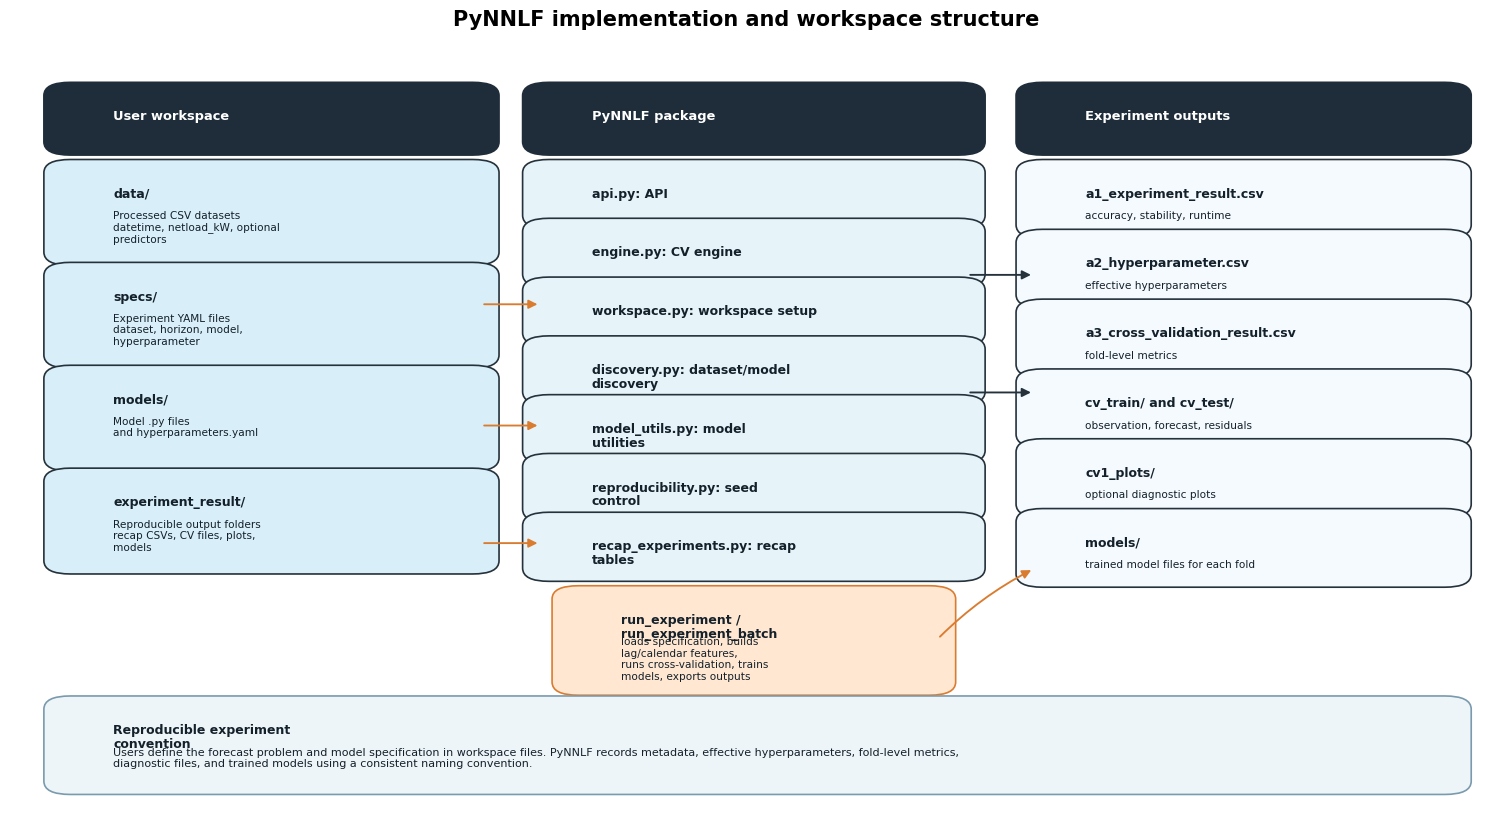

Saved: <local path redacted>


In [4]:
fig, ax = plt.subplots(figsize=(15.0, 8.2))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

# Main columns
section_header(ax, 0.035, 0.895, 0.285, "User workspace")
section_header(ax, 0.360, 0.895, 0.29, "PyNNLF package")
section_header(ax, 0.695, 0.895, 0.285, "Experiment outputs")

item_stack(ax, 0.035, 0.865, 0.285, 0.120, workspace_items, gap=0.020, facecolor=COLORS["light"], body_wrap=34)
item_stack(ax, 0.360, 0.865, 0.29, 0.070, package_items, gap=0.010, facecolor="#E6F3F8", body_size=7.4, body_wrap=34)
item_stack(ax, 0.695, 0.865, 0.285, 0.083, output_items, gap=0.012, facecolor=COLORS["pale"], body_wrap=34)

# Central engine emphasis
rounded_box(
    ax,
    (0.380, 0.160),
    0.250,
    0.125,
    "run_experiment / run_experiment_batch",
    "loads specification, builds lag/calendar features,\nruns cross-validation, trains models, exports outputs",
    facecolor="#FFE7D1",
    edgecolor=COLORS["accent"],
    body_size=7.6,
    body_wrap=34,
)

# Flow arrows
arrow(ax, (0.320, 0.68), (0.360, 0.68), color=COLORS["accent"])
arrow(ax, (0.320, 0.515), (0.360, 0.515), color=COLORS["accent"])
arrow(ax, (0.320, 0.355), (0.360, 0.355), color=COLORS["accent"])
arrow(ax, (0.630, 0.225), (0.695, 0.320), color=COLORS["accent"], rad=-0.08)
arrow(ax, (0.650, 0.72), (0.695, 0.72), color=COLORS["line"])
arrow(ax, (0.650, 0.56), (0.695, 0.56), color=COLORS["line"])

# Explanatory bottom band
rounded_box(
    ax,
    (0.035, 0.025),
    0.945,
    0.110,
    "Reproducible experiment convention",
    "Users define the forecast problem and model specification in workspace files. PyNNLF records metadata, effective hyperparameters, fold-level metrics, diagnostic files, and trained models using a consistent naming convention.",
    facecolor="#EEF5F8",
    edgecolor="#7A9AAD",
    body_size=8.0,
    body_wrap=150,
)

fig.suptitle("PyNNLF implementation and workspace structure", fontsize=15, fontweight="bold", y=0.985)
fig.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig(FIGURE_PATH, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {FIGURE_PATH}")

## 6. Saved File Summary

In [5]:
if not FIGURE_PATH.exists():
    raise FileNotFoundError(FIGURE_PATH)

print(f"Figure path: {FIGURE_PATH}")
print(f"File size: {FIGURE_PATH.stat().st_size:,} bytes")

Figure path: <local path redacted>
File size: 589,832 bytes
